In [1]:
import pandas as pd
from pathlib import Path
csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_timbre_metrics.csv")
df = pd.read_csv(csv_path)

Index(['img_id', 'batch_day', 'area_um2', 'perimeter_um', 'major_um',
       'minor_um', 'circularity', 'solidity', 'convexity', 'aspect_ratio',
       'xor_curve', 'marginal_diff', 'cumulative_diff', 'entropy'],
      dtype='object')
         img_id batch_day       area_um2  perimeter_um    major_um  \
0   BA4 Dy03 A1  BA4_Dy03  274618.720760   1951.342886  607.114442   
1  BA4 Dy03 A10  BA4_Dy03  252607.918879   1879.410789  585.143932   
2  BA4 Dy03 A11  BA4_Dy03  246520.981074   1858.559380  567.341100   
3  BA4 Dy03 A12  BA4_Dy03  237879.703299   1816.856561  559.072128   
4   BA4 Dy03 A2  BA4_Dy03  274510.025442   1948.072253  611.974602   

     minor_um  circularity  solidity  convexity  aspect_ratio  \
0  576.384282     0.906302  0.985951   1.000000      1.053315   
1  550.550608     0.898697  0.984537   1.000000      1.062834   
2  555.229009     0.896832  0.982456   0.997676      1.021815   
3  543.320352     0.905578  0.985589   1.000000      1.028992   
4  572.262703     0

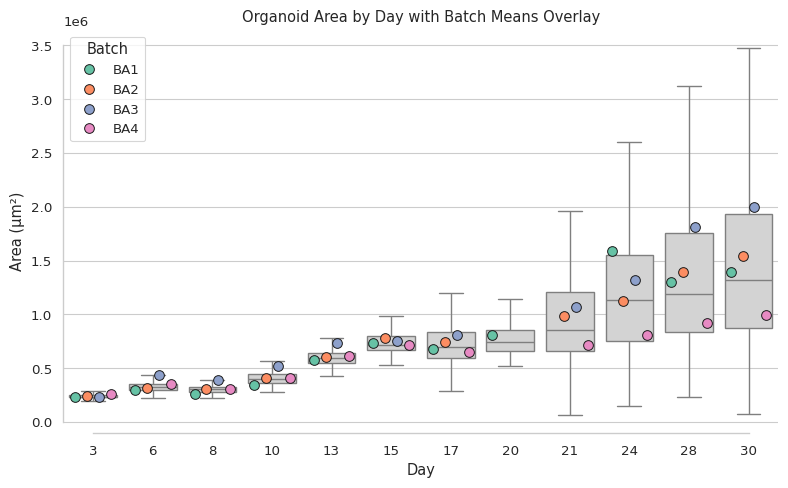

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd

csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/morphology_timbre_metrics.csv")
df = pd.read_csv(csv_path)
print(df.columns)
print(df.head())

# Extract BA (e.g., BA4) and Day (e.g., 03)
df["batch"] = df["batch_day"].str.extract(r"(BA\d)")
df["day"]   = df["batch_day"].str.extract(r"Dy(\d{2})").astype(int)
print(df[["batch_day", "batch", "day"]].drop_duplicates())

# --- Step 4: Compute batch-day means for overlay ---
metric = "area_um2"
means = df.groupby(["batch", "day"])[metric].mean().reset_index()

# --- Step 5: Plot ---
sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8, 5))

# A) Boxplot of all values by day (no hue)
ax = sns.boxplot(data=df, x="day", y=metric, color="lightgray", showfliers=False)

# B) Overlay batch-wise mean values as dots
sns.stripplot(
    data=means,
    x="day", y=metric, hue="batch",
    dodge=True, palette="Set2",
    size=7, marker="o", edgecolor="k", linewidth=0.7,
    ax=ax
)

# --- Final formatting ---
ax.set_title("Organoid Area by Day with Batch Means Overlay")
ax.set_ylabel("Area (µm²)")
ax.set_xlabel("Day")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()


In [3]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
# Load original mapping JSON
with open("/net/projects2/promega/data-analysis/output/image_mapping.json") as f:
    mapping = json.load(f)

# Convert to DataFrame
meta_df = pd.DataFrame.from_dict(mapping, orient="index")
meta_df["img_id"] = meta_df.index

# Merge treatment and cellLine into df
df = df.merge(meta_df[["img_id", "treatment", "cellLine"]], on="img_id", how="left")





In [4]:
df_with_treatment = df[df["treatment"].notna()]
df_no_treatment = df[df["treatment"].isna()]

df_kp9_treat     = df[(df["cellLine"] == "KP9") & (df["treatment"].notna())]
df_kp9_control   = df[(df["cellLine"] == "KP9") & (df["treatment"].isna())]

df_gm_treat      = df[(df["cellLine"] == "GM23279A") & (df["treatment"].notna())]
df_gm_control    = df[(df["cellLine"] == "GM23279A") & (df["treatment"].isna())]


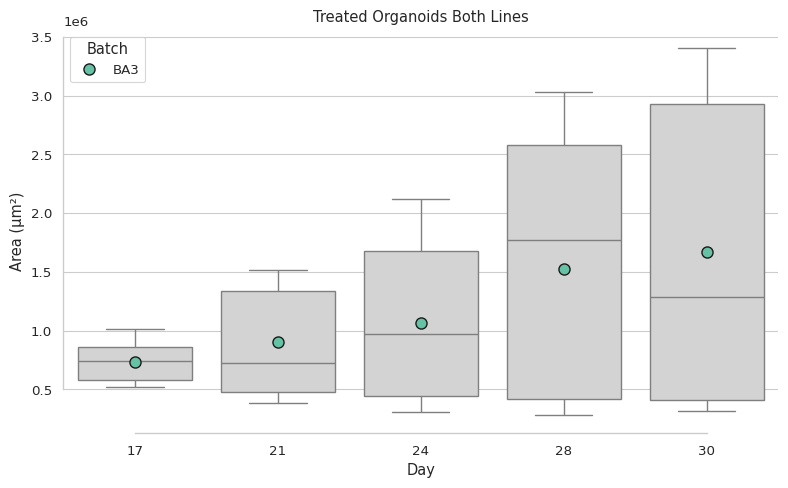

In [5]:
metric = "area_um2"
df_treated = df[df["treatment"].notna()]

means_treated = df_treated.groupby(["batch", "day"])[metric].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_treated, x="day", y=metric,
    color="lightgray", showfliers=False
)

sns.stripplot(
    data=means_treated, x="day", y=metric,
    hue="batch", dodge=True, palette="Set2",
    size=8, marker="o", edgecolor="k", linewidth=1, ax=ax
)

ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Treated Organoids Both Lines")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()



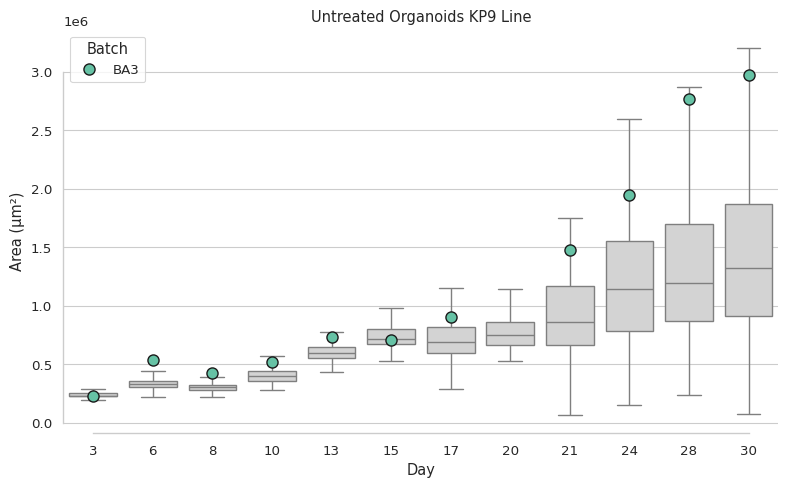

In [6]:
df_untreated = df[df["treatment"].isna()]
means_untreated = df_kp9_control.groupby(["batch", "day"])[metric].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_untreated, x="day", y=metric,
    color="lightgray", showfliers=False
)

sns.stripplot(
    data=means_untreated, x="day", y=metric,
    hue="batch", dodge=True, palette="Set2",
    size=8, marker="o", edgecolor="k", linewidth=1, ax=ax
)

ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Untreated Organoids KP9 Line")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()


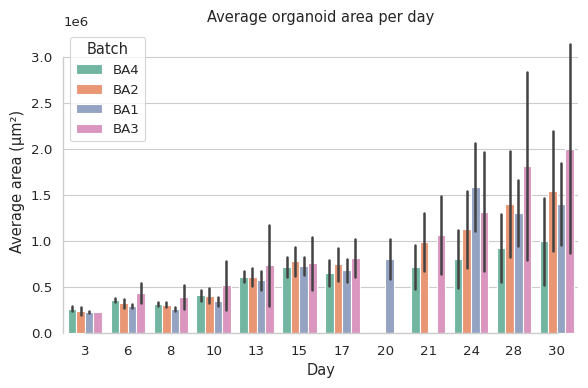

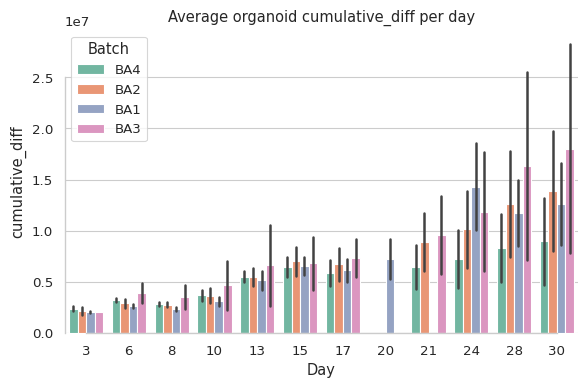

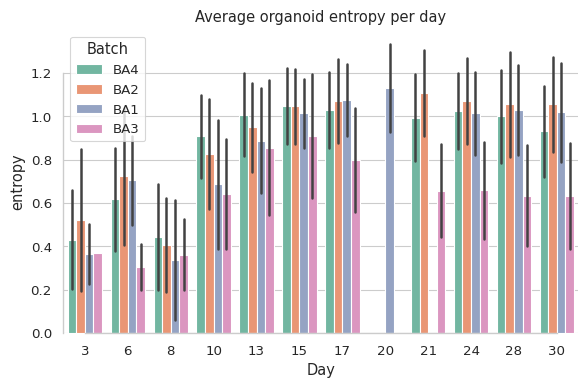

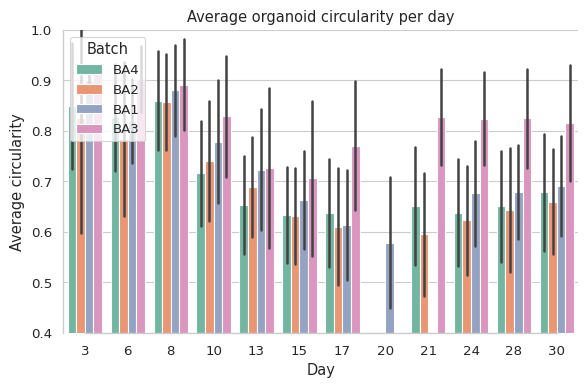

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Seaborn theme
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="DejaVu Sans",
    font_scale=1.1
)

# Function for bar plots
def plot_bar(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df, x="day", y=metric, hue="batch",
        errorbar="sd", palette="Set2"
    )
    plt.ylabel(ylabel)
    plt.xlabel("Day")
    plt.title(title)
    if ylim:
        plt.ylim(ylim)
    plt.legend(title="Batch", loc="upper left")
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

# Plotting
plot_bar("area_um2", "Average area (µm²)", "Average organoid area per day")
plot_bar("cumulative_diff", "cumulative_diff", "Average organoid cumulative_diff per day")
plot_bar("entropy", "entropy", "Average organoid entropy per day")
plot_bar("circularity", "Average circularity", "Average organoid circularity per day", ylim=(0.4, 1))


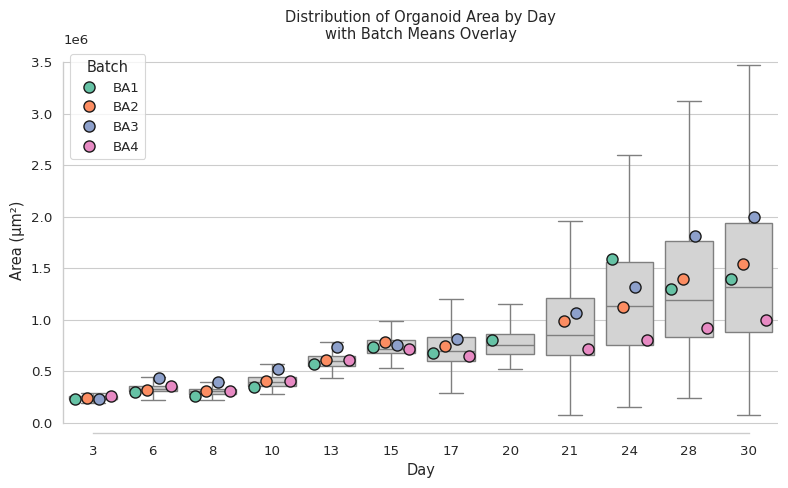

In [5]:


metric = "area_um2"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Distribution of Organoid Area by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

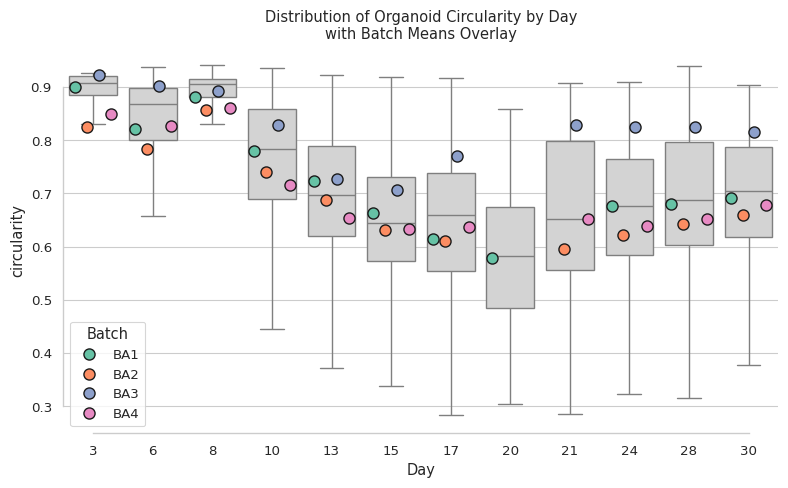

In [8]:
metric = "circularity"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("circularity")
ax.set_title("Distribution of Organoid Circularity by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="lower left")
plt.tight_layout()
plt.show()

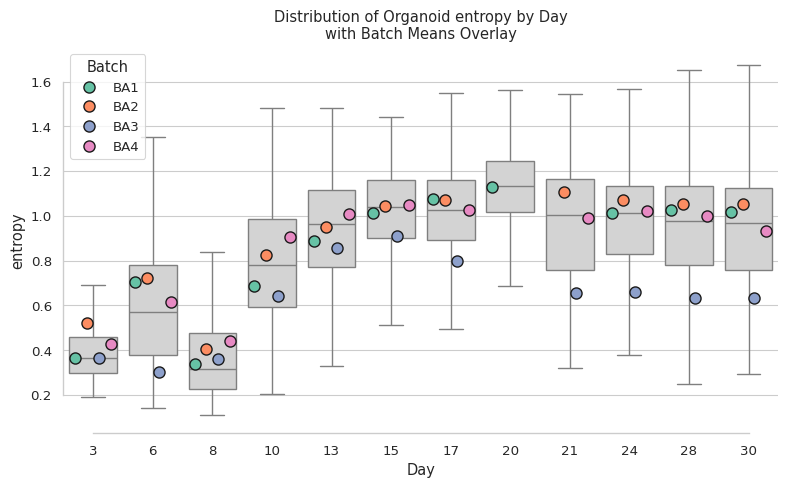

In [9]:
metric = "entropy"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("entropy")
ax.set_title("Distribution of Organoid entropy by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
# print how many rows are in df
print(f"Number of rows in df: {len(df)}")

Number of rows in df: 5165


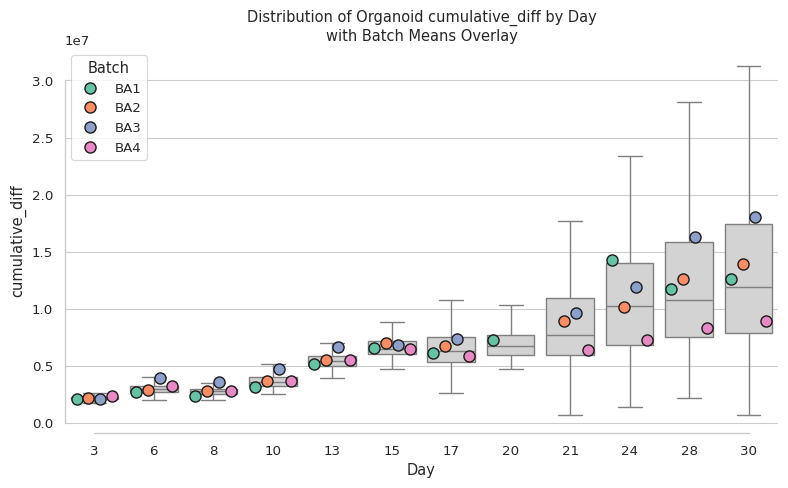

In [8]:
metric = "cumulative_diff"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))


# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("cumulative_diff")
ax.set_title("Distribution of Organoid cumulative_diff by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

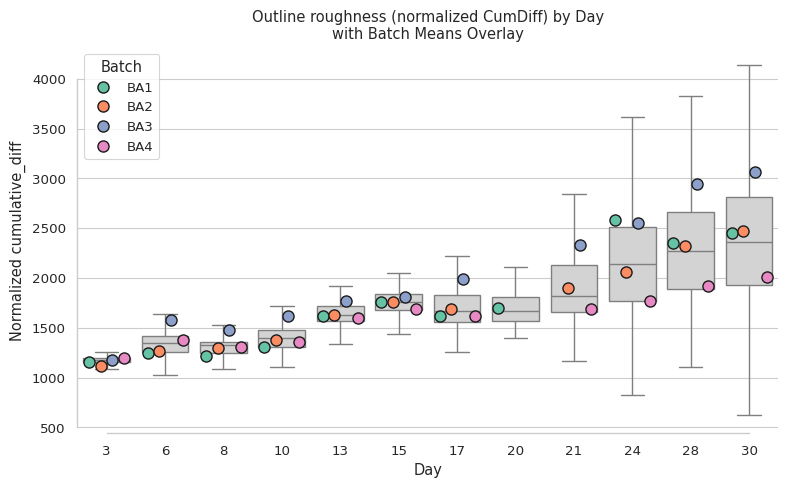

In [9]:
# 0) Normalize
df["norm_cumdiff"] = df["cumulative_diff"] / df["perimeter_um"]

# 1) Choose metric
metric = "norm_cumdiff"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="sans-serif",
    font_scale=1.1
)

plt.figure(figsize=(8,5))

# A) grey boxplot of *all* data
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) overlay batch means
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    dodge=True,
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Polish
ax.set_xlabel("Day")
ax.set_ylabel("Normalized cumulative_diff")
ax.set_title("Outline roughness (normalized CumDiff) by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()
